In [ ]:
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import numpy as np
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.model_selection import train_test_split, GroupKFold, KFold
import matplotlib.pyplot as plt
import optuna
from catboost import CatBoostRegressor

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
original_df = pd.read_csv("synthetic_road_accidents_100k.csv") # from https://www.kaggle.com/datasets/ianktoo/simulated-roads-accident-data

<Axes: xlabel='accident_risk', ylabel='Count'>

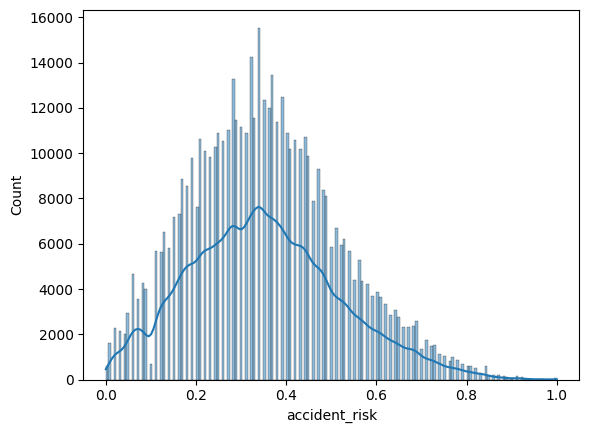

In [ ]:
sns.histplot(train_df['accident_risk'], kde=True)

The peak is clearly in the 0.3-0.4 range, and it's a right-skewed distribution.

KDE confirms the unimodal, right-skewed shape.

The lack of major spikes at 0 or 1 means we don't need a special model (like a Zero-Inflated Beta model); a standard regression approach is fine.

The distribution is not extreme enough to warrant a transformation, especially with RMSE as the metric. A log or sqrt transform would likely distort the error metric and make the model harder to optimize.

In [ ]:
train_df['source'] = 'train'
test_df['source'] = 'test'
original_df['source'] = 'original'

combined_df = pd.concat([train_df, test_df, original_df], ignore_index=True)
display(combined_df.head())

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,source
0,0.0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,train
1,1.0,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,train
2,2.0,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,train
3,3.0,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,train
4,4.0,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,train


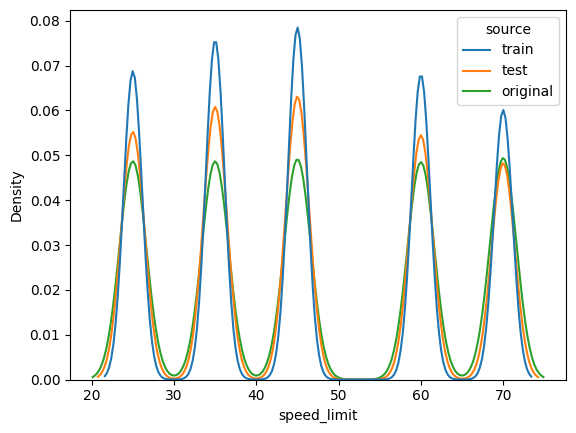

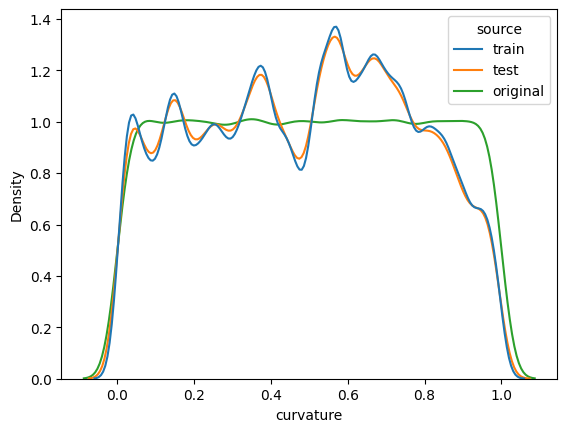

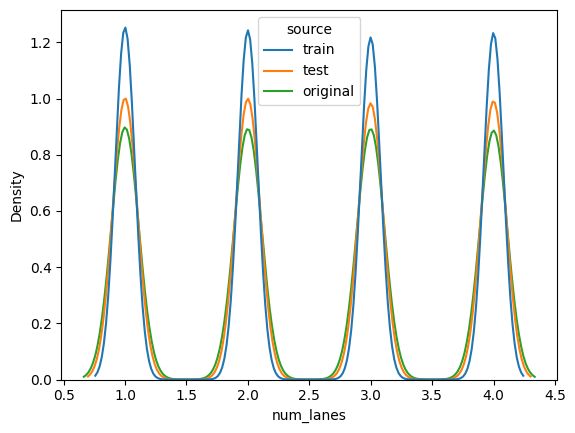

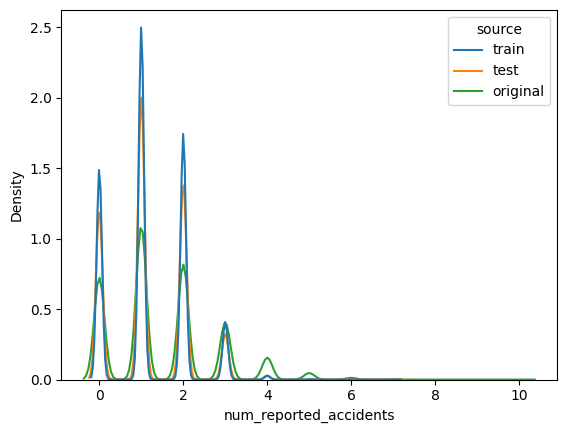

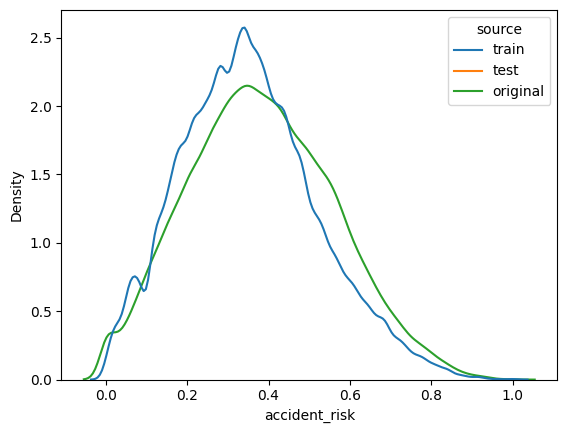

In [ ]:
numeric_features = ['speed_limit', 'curvature', 'num_lanes', 'num_reported_accidents', 'accident_risk']

for feature in numeric_features:
    plt.figure()
    sns.kdeplot(data=combined_df, x=feature, hue='source', common_norm=False)
    plt.show()

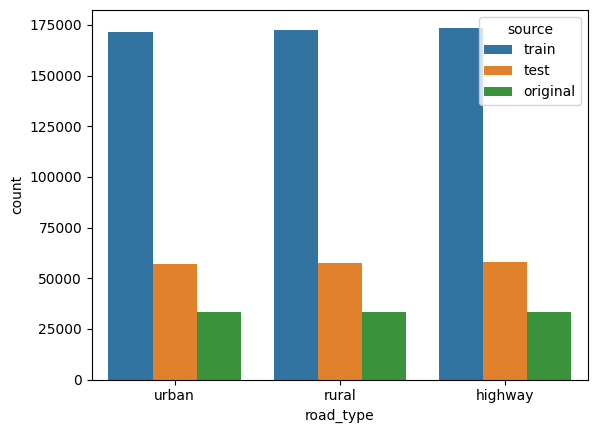

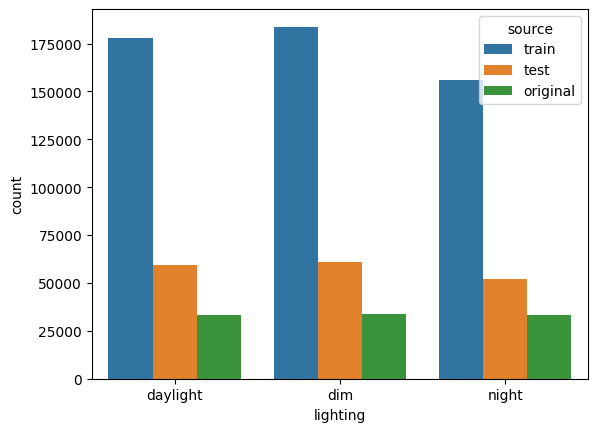

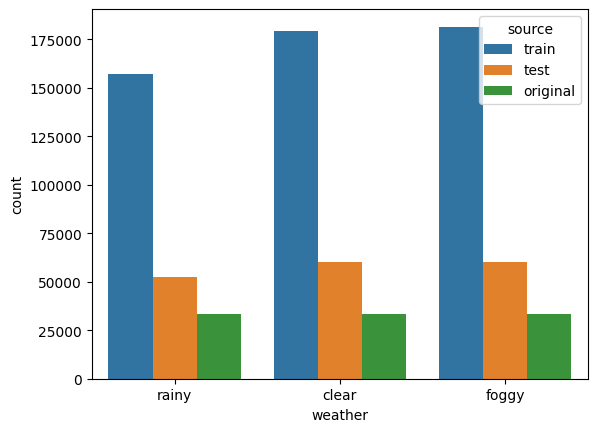

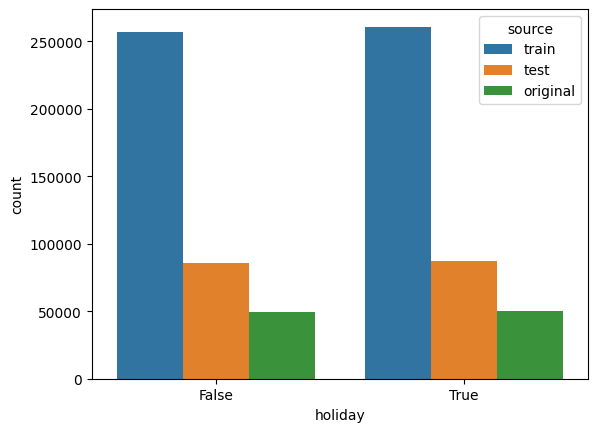

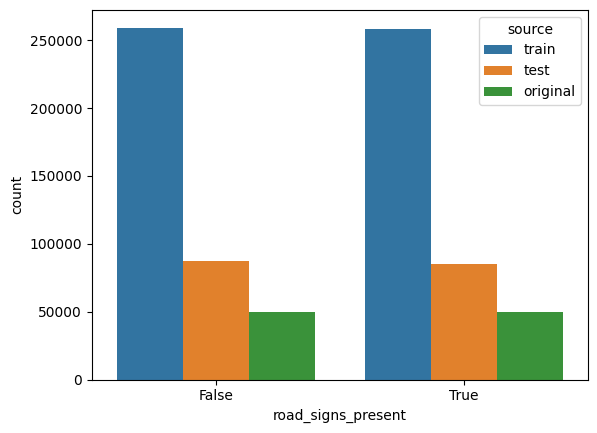

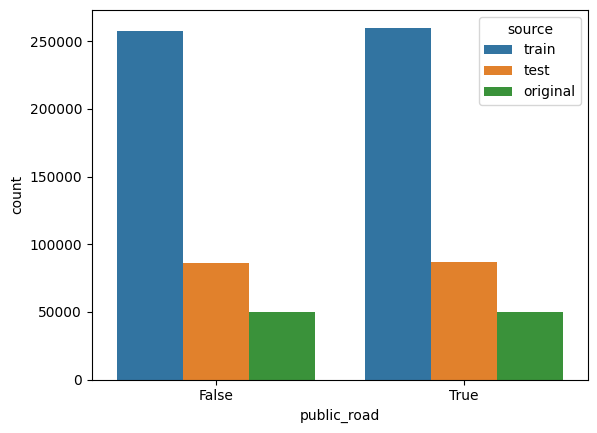

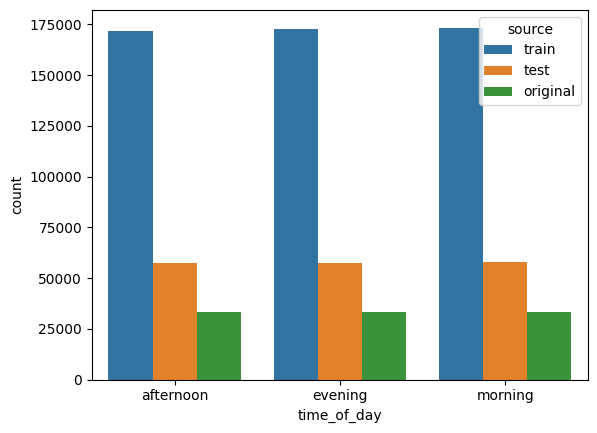

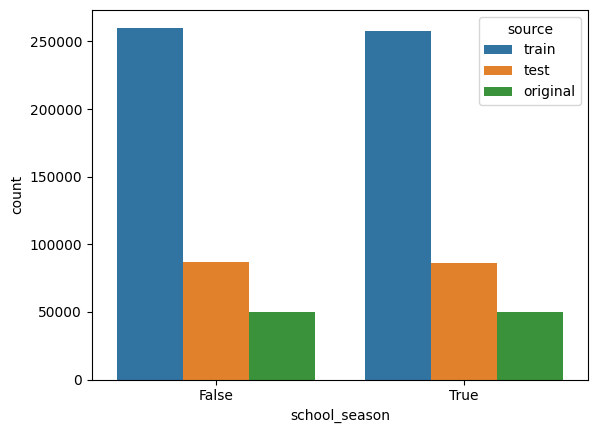

In [ ]:
categorical_features = ['road_type', 'lighting', 'weather', 'holiday', 'road_signs_present', 'public_road', 'time_of_day', 'school_season']
for feature in categorical_features:
    plt.figure()
    sns.countplot(data=combined_df, x=feature, hue='source')
    plt.show()

Speed_limit plot: train test original same shape, five peaks 25 35 45 60 70, heights train highest test middle original lowest, data clean consistent discrete, no distribution shift. Curvature plot: train test overlap perfect, same wavy pattern, no distribution shift, original different flat uniform, train test multimodal 0 to 1, peaks 0.1 0.3 0.55 0.7, data clustered consistent. Num_lanes plot: discrete, peaks at 1 2 3 4, train test original same shape and height, distributions match, split representative, data consistent. Num_reported_accidents plot: discrete count, right-skewed, peaks 1 0 2 3, frequency drops after 3, train test original same shape, distributions match, split consistent. Accident_risk plot: continuous 0 to 1, right-skewed, main peak 0.35, small bump 0.1-0.2, values >0.8 rare, train test original same shape, distributions match, split consistent. Road_type plot: categories urban rural highway, perfectly balanced, train test original same 1:1:1 ratio, distributions match, data unbiased, split consistent. Lighting plot: categories daylight dim night, train test same pattern dim>daylight>night, original balanced, distributions match train/test, original different, split consistent. Weather plot: categories rainy clear foggy, train test same pattern clear≈foggy>rainy, original balanced, distributions match train/test, original different, split consistent. Holiday plot: binary True False, perfectly balanced 50/50, train test original same distribution, split consistent. road_signs_present, public_road: binary True False, 50/50 balanced, train test original same distribution, split consistent. Time_of_day plot: categories morning afternoon evening, perfectly balanced, train test original same distribution, split consistent. school_season: binary True False, perfectly balanced 50/50, train test original same distribution, split consistent.

In [ ]:
train_test_df = combined_df[combined_df['source'].isin(['train', 'test'])].copy()
X = train_test_df.drop(['source', 'id', 'accident_risk'], axis=1)
y = train_test_df['source'] == 'test'
y = y.astype(int)
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
lgb_clf = lgb.LGBMClassifier(objective='binary', metric='auc', random_state=42)
lgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])
y_pred_proba = lgb_clf.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, y_pred_proba)
print("AUC on validation set: ", auc_score)

[LightGBM] [Info] Number of positive: 138068, number of negative: 414203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 177
[LightGBM] [Info] Number of data points in the train set: 552271, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098610
[LightGBM] [Info] Start training from score -1.098610
AUC on validation set:  0.4987473561967614


In [ ]:
static_cols = ['road_type', 'num_lanes', 'speed_limit', 'curvature', 'road_signs_present', 'public_road']
train_df['group_id'] = train_df[static_cols].astype(str).agg('_'.join, axis=1)
test_df['group_id'] = test_df[static_cols].astype(str).agg('_'.join, axis=1)

In [ ]:
print(train_df['group_id'].value_counts())

group_id
rural_1_45_0.57_True_False        60
urban_1_45_0.67_False_True        60
urban_1_60_0.67_True_False        60
highway_2_35_0.57_False_True      59
rural_4_60_0.7_False_False        59
                                  ..
urban_3_25_0.2906_True_True        1
highway_3_60_0.3909_True_False     1
urban_1_45_0.2392_True_True        1
highway_3_45_0.3321_True_False     1
highway_4_25_0.2941_True_False     1
Name: count, Length: 24552, dtype: int64


Group Check: POSITIVE

The value_counts() output confirms we have a strong, clear group structure.

Finding: We have 517,754 total rows but only 24,552 unique group_ids.

Implication: Each unique road segment is sampled, on average, ~21 times (with some appearing up to 60 times). This is a classic "grouped" dataset.

<Axes: title={'center': 'Rolling Mean of accident_risk vs. id'}>

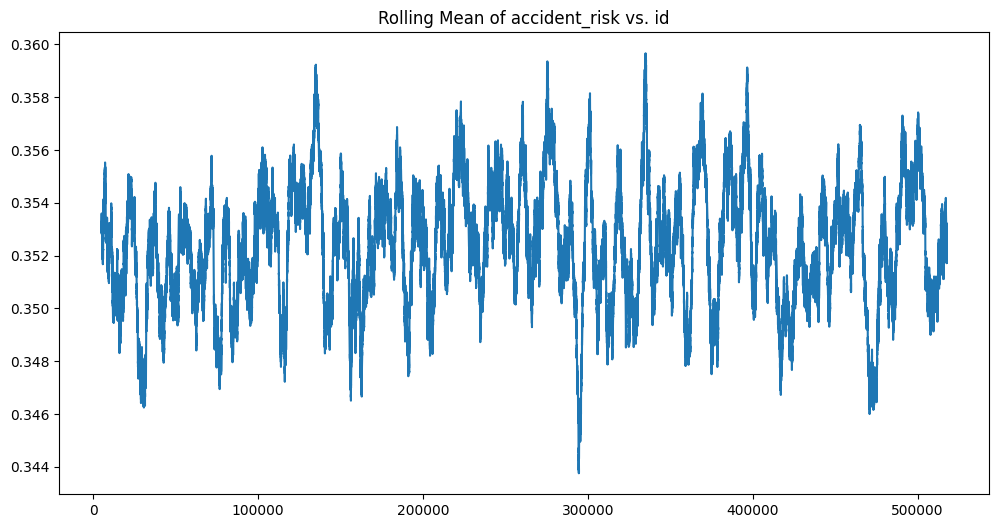

In [ ]:
(train_df.sort_values('id')['accident_risk']
      .rolling(window=5000)
      .mean()
      .plot(figsize=(12, 6), title='Rolling Mean of accident_risk vs. id'))

Time Check: NEGATIVE

The rolling mean plot confirms we do not have a time-dependency problem.

Finding: The plot is a "fuzzy caterpillar." It's a flat, noisy line oscillating around a stable mean (approx. 0.353). There is no upward/downward trend, no sudden changepoints, and no change in variance.

Implication: The id column is just a random identifier, not a sequential time index.

Data Triage & EDA (Complete)
This phase is complete. Our key conclusions that now drive the plan are:

Target: Model accident_risk directly. No transformation needed.

Adversarial Validation:

train vs. test: AUC ~= 0.5 proves there is no distribution shift. This is excellent news. It means our local GroupKFold RMSE will be 100% reliable and directly reflect leaderboard performance.

train vs. original: Our EDA confirmed (lighting, weather) that the original dataset has a different distribution. This makes it perfect for creating transfer features but risky to simply concatenate.

In [ ]:
X_pure = train_df.drop(columns=['accident_risk', 'id', 'source', 'group_id'])
y_pure = train_df['accident_risk']
groups_pure = train_df['group_id']
X_pure = pd.get_dummies(X_pure, columns=categorical_features, drop_first=True)
gkf_pure = GroupKFold(n_splits=10)
oof_preds_pure = np.zeros(len(X_pure))
rmse_scores_pure = []

for fold, (train_idx, val_idx) in enumerate(gkf_pure.split(X_pure, y_pure, groups_pure)):
    X_train, y_train = X_pure.iloc[train_idx], y_pure.iloc[train_idx]
    X_val, y_val = X_pure.iloc[val_idx], y_pure.iloc[val_idx]
    lgb_reg_pure = lgb.LGBMRegressor(objective='regression', metric='rmse', random_state=42)
    lgb_reg_pure.fit(X_train, y_train,
                     eval_set=[(X_val, y_val)],
                     eval_metric='rmse',
                     callbacks=[lgb.early_stopping(100, verbose=False)])

    oof_preds_pure[val_idx] = lgb_reg_pure.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds_pure[val_idx]))
    rmse_scores_pure.append(fold_rmse)

rmse_pure_base = np.sqrt(mean_squared_error(y_pure, oof_preds_pure))
print(f"RMSE_pure_base (Original Features Only): {rmse_pure_base}")
print(f"Mean Fold RMSE (Original Features Only): {np.mean(rmse_scores_pure)}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024366 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 465978, number of used features: 16
[LightGBM] [Info] Start training from score 0.352380
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 169
[LightGBM] [Info] Number of data points in the train set: 465978, number of used features: 16
[LightGBM] [Info] Start training from score 0.352176
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

In [ ]:
!pip install optuna-integration[lightgbm]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
X_pure = train_df.drop(columns=['accident_risk', 'id', 'source', 'group_id'])
y_pure = train_df['accident_risk']
groups_pure = train_df['group_id']
X_pure = pd.get_dummies(X_pure, columns=categorical_features, drop_first=True)

from optuna.integration import LightGBMPruningCallback

gkf_pure = GroupKFold(n_splits=10)
oof_preds_pure = np.zeros(len(X_pure))
rmse_scores_pure = []
best_hyperparams_per_fold = []

optuna.logging.set_verbosity(optuna.logging.WARNING)

for fold, (train_idx, val_idx) in enumerate(gkf_pure.split(X_pure, y_pure, groups_pure)):
    print(f"\nStarting Fold {fold+1}/{gkf_pure.n_splits}")
    X_train, y_train = X_pure.iloc[train_idx], y_pure.iloc[train_idx]
    X_val, y_val = X_pure.iloc[val_idx], y_pure.iloc[val_idx]

    def objective(trial):
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'random_state': 42,
            'n_estimators': 2000,
            'verbose': -1,
            'device': 'gpu',
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }

        lgb_reg = lgb.LGBMRegressor(**params)
        pruning_callback = LightGBMPruningCallback(trial, 'rmse')

        lgb_reg.fit(X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    eval_metric='rmse',
                    callbacks=[lgb.early_stopping(100, verbose=False), pruning_callback])

        preds = lgb_reg.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        return rmse

    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
    study.optimize(objective, n_trials=20, show_progress_bar=True)

    best_params = study.best_params
    best_hyperparams_per_fold.append(best_params)

    final_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'random_state': 42,
        'n_estimators': 2000,
        'verbose': -1,
        'device': 'gpu',
        **best_params
    }

    lgb_reg_pure = lgb.LGBMRegressor(**final_params)
    lgb_reg_pure.fit(X_train, y_train,
                     eval_set=[(X_val, y_val)],
                     eval_metric='rmse',
                     callbacks=[lgb.early_stopping(100, verbose=False)])

    oof_preds_pure[val_idx] = lgb_reg_pure.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds_pure[val_idx]))
    rmse_scores_pure.append(fold_rmse)
    print(f"Fold {fold+1} RMSE: {fold_rmse}")

rmse_pure_base = np.sqrt(mean_squared_error(y_pure, oof_preds_pure))
print(f"\nRMSE_pure_base (Tuned Features Only): {rmse_pure_base}")
print(f"Mean Fold RMSE (Tuned Features Only): {np.mean(rmse_scores_pure)}")


Starting Fold 1/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 1 RMSE: 0.05578802769333482

Starting Fold 2/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 2 RMSE: 0.05570140746719338

Starting Fold 3/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 3 RMSE: 0.05621913926805691

Starting Fold 4/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 4 RMSE: 0.05656513099473936

Starting Fold 5/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 5 RMSE: 0.05618957570696403

Starting Fold 6/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 6 RMSE: 0.05623325091669342

Starting Fold 7/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 7 RMSE: 0.05585467729535027

Starting Fold 8/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 8 RMSE: 0.05612080373270366

Starting Fold 9/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 9 RMSE: 0.055754669309225735

Starting Fold 10/10


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 10 RMSE: 0.055805053045034955

RMSE_pure_base (Tuned Features Only): 0.0560238168078305
Mean Fold RMSE (Tuned Features Only): 0.05602317354292965


In [ ]:
features_to_remove = [
    'is_original',
    'speed_limit_to_lanes_ratio',
    'holiday',
    'public_road',
    'time_of_day',
    'school_season',
    'road_signs_present'
]

train_df_refined = train_df.copy()
original_df_refined = original_df.copy()
train_df_refined['speed_limit_x_curvature'] = train_df_refined['speed_limit'] * train_df_refined['curvature']
original_df_refined['speed_limit_x_curvature'] = original_df_refined['speed_limit'] * original_df_refined['curvature']
train_df_refined = train_df_refined.drop(columns=features_to_remove, errors='ignore')
original_df_refined = original_df_refined.drop(columns=features_to_remove, errors='ignore')

print("Features: ", train_df_refined.columns)
print("Original Features: ", original_df_refined.columns)

Features:  Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'num_reported_accidents', 'accident_risk', 'source',
       'group_id', 'speed_limit_x_curvature'],
      dtype='object')
Original Features:  Index(['road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'num_reported_accidents', 'accident_risk', 'source',
       'speed_limit_x_curvature'],
      dtype='object')


In [ ]:
train_df_cat = train_df_refined.copy()
original_df_cat = original_df_refined.copy()
train_df_cat['speed_limit_to_lanes_ratio'] = train_df_cat['speed_limit'] / train_df_cat['num_lanes']
train_df_cat['speed_limit_x_curvature'] = train_df_cat['speed_limit'] * train_df_cat['curvature']
original_df_cat['speed_limit_to_lanes_ratio'] = original_df_cat['speed_limit'] / original_df_cat['num_lanes']
original_df_cat['speed_limit_x_curvature'] = original_df_cat['speed_limit'] * original_df_cat['curvature']
train_df_cat['is_original'] = 0
original_df_cat['is_original'] = 1
feature_cols = [col for col in train_df_cat.columns if col not in ['id', 'group_id', 'source', 'accident_risk']]
if 'is_original' not in feature_cols: feature_cols.append('is_original')
train_part_cols = feature_cols + ['accident_risk']
original_part_cols = feature_cols
train_part = train_df_cat[train_part_cols]
original_part_features_present = [col for col in original_part_cols if col in original_df_cat.columns]
original_part = original_df_cat[original_part_features_present].copy()
for col in original_part_cols:
    if col not in original_part.columns:
        original_part[col] = np.nan
original_part = original_part[original_part_cols]
train_combined_cat = pd.concat([train_part, original_part], ignore_index=True)
X_cat_ref = train_df_cat.drop(columns=['accident_risk', 'id', 'source', 'group_id', 'is_original'])
y_cat_ref = train_df_cat['accident_risk']
groups_cat_ref = train_df_cat['group_id']
X_cat_comb = train_combined_cat.drop(columns=['accident_risk', 'id'], errors='ignore')
y_cat_comb = train_combined_cat['accident_risk']
is_original_series_cat = (train_combined_cat['is_original'] == 1)
bool_cols = X_cat_comb.select_dtypes(include=['bool']).columns
X_cat_comb[bool_cols] = X_cat_comb[bool_cols].astype(int)
potential_bool_objects = ['road_signs_present', 'public_road', 'holiday', 'school_season']
for col in potential_bool_objects:
    if col in X_cat_comb.columns and X_cat_comb[col].dtype == 'object':
         X_cat_comb[col] = X_cat_comb[col].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(-1).astype(int)
categorical_features_catboost = ['road_type', 'lighting', 'weather', 'time_of_day']
categorical_features_catboost = [col for col in categorical_features_catboost if col in X_cat_comb.columns]
cat_feature_indices = [X_cat_comb.columns.get_loc(col) for col in categorical_features_catboost]
gkf = GroupKFold(n_splits=10)
oof_preds_cat = np.zeros(len(train_df_cat))
rmse_scores_cat = []
test_df_cat = test_df.copy()
test_df_cat['speed_limit_to_lanes_ratio'] = test_df_cat['speed_limit'] / test_df_cat['num_lanes']
test_df_cat['speed_limit_x_curvature'] = test_df_cat['speed_limit'] * test_df_cat['curvature']
test_df_cat['is_original'] = 0
bool_cols_test = test_df_cat.select_dtypes(include=['bool']).columns
test_df_cat[bool_cols_test] = test_df_cat[bool_cols_test].astype(int)
for col in potential_bool_objects:
    if col in test_df_cat.columns and test_df_cat[col].dtype == 'object':
         test_df_cat[col] = test_df_cat[col].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(-1).astype(int)
X_test_cat = test_df_cat.drop(columns=['id', 'source', 'group_id'], errors='ignore')
X_test_cat = X_test_cat[X_cat_comb.columns]
test_preds_cat = np.zeros(len(X_test_cat))
original_data_indices = X_cat_comb[is_original_series_cat].index

for fold, (train_base_idx, val_base_idx) in enumerate(gkf.split(X_cat_ref, y_cat_ref, groups_cat_ref)):
    X_val, y_val = X_cat_comb.iloc[val_base_idx], y_cat_comb.iloc[val_base_idx]
    combined_train_indices = np.concatenate([train_base_idx, original_data_indices])
    X_train_fold_full, y_train_fold_full = X_cat_comb.iloc[combined_train_indices], y_cat_comb.iloc[combined_train_indices]
    not_nan_target_idx = y_train_fold_full.notna()
    X_train_fold = X_train_fold_full[not_nan_target_idx]
    y_train_fold = y_train_fold_full[not_nan_target_idx]
    cat_model = CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=42, early_stopping_rounds=100, verbose=500)
    cat_model.fit(X_train_fold, y_train_fold, eval_set=(X_val, y_val), cat_features=cat_feature_indices)
    oof_preds_cat[val_base_idx] = cat_model.predict(X_val)
    test_preds_cat += cat_model.predict(X_test_cat) / gkf.n_splits
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds_cat[val_base_idx]))
    rmse_scores_cat.append(fold_rmse)
    print(f"Fold {fold+1} RMSE: {fold_rmse}")
rmse_catboost = np.sqrt(mean_squared_error(y_cat_ref, oof_preds_cat))
print(f"\nOverall OOF RMSE with CatBoost (Combined Data): {rmse_catboost}")

Learning rate set to 0.133607
0:	learn: 0.1490970	test: 0.1508221	best: 0.1508221 (0)	total: 820ms	remaining: 13m 39s
500:	learn: 0.0559410	test: 0.0559258	best: 0.0559258 (500)	total: 3m 50s	remaining: 3m 49s
999:	learn: 0.0556654	test: 0.0558730	best: 0.0558729 (981)	total: 7m 30s	remaining: 0us

bestTest = 0.05587293968
bestIteration = 981

Shrink model to first 982 iterations.
Fold 1 RMSE: 0.055872940003363854
Learning rate set to 0.133607
0:	learn: 0.1490529	test: 0.1499565	best: 0.1499565 (0)	total: 486ms	remaining: 8m 5s
500:	learn: 0.0558806	test: 0.0558149	best: 0.0558145 (499)	total: 3m 34s	remaining: 3m 34s
999:	learn: 0.0556354	test: 0.0557749	best: 0.0557749 (999)	total: 7m 2s	remaining: 0us

bestTest = 0.05577493432
bestIteration = 999

Fold 2 RMSE: 0.055774934585497274
Learning rate set to 0.133607
0:	learn: 0.1494068	test: 0.1470074	best: 0.1470074 (0)	total: 496ms	remaining: 8m 15s
500:	learn: 0.0558211	test: 0.0563050	best: 0.0563049 (499)	total: 3m 29s	remaining: 3m 

--- Starting HPO Phase ---
Best hyperparameters found: {'depth': 7, 'learning_rate': 0.0673054043547808, 'l2_leaf_reg': 2.876110203298637, 'iterations': 1218, 'verbose': 500, 'early_stopping_rounds': 100, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'random_seed': 42, 'task_type': 'GPU'}

--- Starting Final 10-Fold CV with Best Parameters ---
--- Fold 1 ---
0:	learn: 0.1566980	test: 0.1585319	best: 0.1585319 (0)	total: 79.4ms	remaining: 3m 58s
500:	learn: 0.0560101	test: 0.0560416	best: 0.0560414 (499)	total: 17.1s	remaining: 1m 25s
1000:	learn: 0.0557603	test: 0.0560126	best: 0.0560111 (935)	total: 33.3s	remaining: 1m 6s
bestTest = 0.05601112172
bestIteration = 935
Shrink model to first 936 iterations.
Fold 1 RMSE: 0.056011122515075694
--- Fold 2 ---
0:	learn: 0.1567965	test: 0.1577671	best: 0.1577671 (0)	total: 30.4ms	remaining: 1m 31s
500:	learn: 0.0560220	test: 0.0559454	best: 0.0559452 (499)	total: 17s	remaining: 1m 25s
1000:	learn: 0.0557563	test: 0.0559077	best: 0.0559062 (90

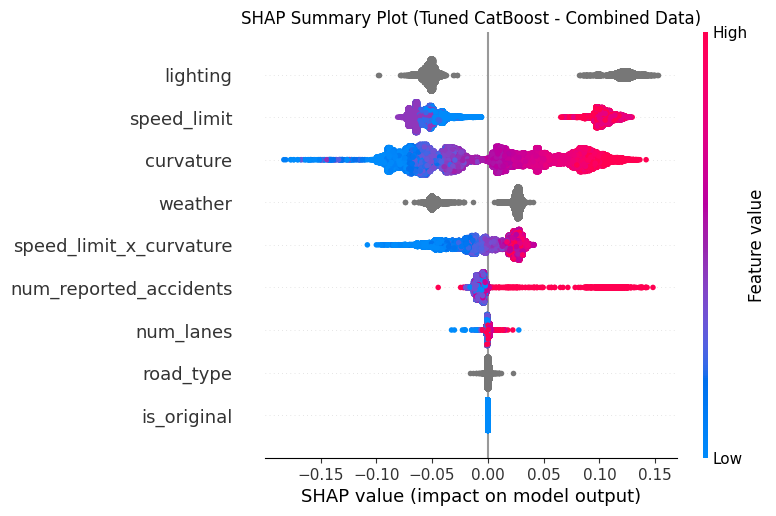


--- Average Feature Importance (SHAP) ---
                   feature  shap_importance
4                 lighting         0.073465
3              speed_limit         0.072512
2                curvature         0.055873
5                  weather         0.034144
7  speed_limit_x_curvature         0.023314
6   num_reported_accidents         0.013928
1                num_lanes         0.000821
0                road_type         0.000405
8              is_original         0.000000

Importance of 'speed_limit_x_curvature':
                   feature  shap_importance
7  speed_limit_x_curvature         0.023314

Potentially Prunable Features (Low SHAP Importance):
       feature  shap_importance
1    num_lanes         0.000821
0    road_type         0.000405
8  is_original         0.000000

Submission file 'submission_catboost_tuned.csv' created.


In [ ]:
import pandas as pd
import numpy as np
import catboost as cb
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
import shap
import joblib
import os
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
original_df = pd.read_csv("synthetic_road_accidents_100k.csv")
static_cols = ['road_type', 'num_lanes', 'speed_limit', 'curvature', 'road_signs_present', 'public_road']
train_df['group_id'] = train_df[static_cols].astype(str).agg('_'.join, axis=1)
test_df['group_id'] = test_df[static_cols].astype(str).agg('_'.join, axis=1)
original_df['group_id'] = original_df[static_cols].astype(str).agg('_'.join, axis=1)
train_df['source'] = 'train'
test_df['source'] = 'test'
original_df['source'] = 'original'

train_df_cat = train_df.copy()
original_df_cat = original_df.copy()
test_df_cat = test_df.copy()

train_df_cat['speed_limit_x_curvature'] = train_df_cat['speed_limit'] * train_df_cat['curvature']
original_df_cat['speed_limit_x_curvature'] = original_df_cat['speed_limit'] * original_df_cat['curvature']
test_df_cat['speed_limit_x_curvature'] = test_df_cat['speed_limit'] * test_df_cat['curvature']

features_to_keep = [
    'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
    'weather', 'num_reported_accidents', 'speed_limit_x_curvature',
    'accident_risk', 'group_id'
]
categorical_features_catboost = ['road_type', 'lighting', 'weather']

train_part = train_df_cat[features_to_keep].copy()
original_part = original_df_cat[[col for col in features_to_keep if col != 'accident_risk']].copy()
original_part['accident_risk'] = np.nan
test_part = test_df_cat[[col for col in features_to_keep if col not in ['accident_risk', 'source']]].copy() # Keep group_id for test

train_part['is_original'] = 0
original_part['is_original'] = 1

train_combined_cat_hpo = pd.concat([train_part, original_part], ignore_index=True)

final_feature_cols = [col for col in train_combined_cat_hpo.columns if col not in ['id', 'source', 'accident_risk', 'group_id']]
categorical_features_final = [col for col in categorical_features_catboost if col in final_feature_cols]

for col in categorical_features_final:
    train_combined_cat_hpo[col] = train_combined_cat_hpo[col].astype('category')
    test_part[col] = test_part[col].astype('category')

X_hpo = train_combined_cat_hpo[train_combined_cat_hpo['is_original'] == 0].drop(columns=['accident_risk', 'group_id'])
y_hpo = train_combined_cat_hpo[train_combined_cat_hpo['is_original'] == 0]['accident_risk']

X_train_hpo, X_val_hpo, y_train_hpo, y_val_hpo = train_test_split(
    X_hpo, y_hpo, test_size=0.2, random_state=42
)

cat_feature_indices_hpo = [X_train_hpo.columns.get_loc(col) for col in categorical_features_final]

print("--- Starting HPO Phase ---")

def objective(trial):
    params = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 100,
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'iterations': trial.suggest_int('iterations', 800, 3000),
        'task_type': 'GPU',
    }

    model = cb.CatBoostRegressor(**params)
    model.fit(X_train_hpo, y_train_hpo,
              eval_set=(X_val_hpo, y_val_hpo),
              cat_features=cat_feature_indices_hpo,
              early_stopping_rounds=100
             )
    best_iteration = model.get_best_iteration()
    trial.set_user_attr('best_iteration', best_iteration)

    return model.get_best_score()['validation']['RMSE']

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

best_params_cat = study.best_params
best_params_cat['iterations'] = study.best_trial.user_attrs.get('best_iteration', best_params_cat['iterations'])
best_params_cat['verbose'] = 500
best_params_cat['early_stopping_rounds'] = 100
best_params_cat['loss_function'] = 'RMSE'
best_params_cat['eval_metric'] = 'RMSE'
best_params_cat['random_seed'] = 42
if 'task_type' not in best_params_cat:
    best_params_cat['task_type'] = 'GPU'

best_params_cat.pop('colsample_bylevel', None)

print(f"Best hyperparameters found: {best_params_cat}")
print("\n--- Starting Final 10-Fold CV with Best Parameters ---")

X_cat_full = train_combined_cat_hpo[final_feature_cols]
y_cat_full = train_combined_cat_hpo['accident_risk']
groups_cat_full = train_combined_cat_hpo['group_id']
is_original_series_cat_full = (train_combined_cat_hpo['is_original'] == 1)
original_data_indices_full = X_cat_full[is_original_series_cat_full].index

X_cat_ref_final = train_combined_cat_hpo[train_combined_cat_hpo['is_original'] == 0][final_feature_cols]
y_cat_ref_final = train_combined_cat_hpo[train_combined_cat_hpo['is_original'] == 0]['accident_risk']
groups_cat_ref_final = train_combined_cat_hpo[train_combined_cat_hpo['is_original'] == 0]['group_id']

cat_feature_indices_full = [X_cat_full.columns.get_loc(col) for col in categorical_features_final]

gkf_final = GroupKFold(n_splits=10)
oof_preds_cat_tuned = np.zeros(len(X_cat_ref_final))
rmse_scores_cat_tuned = []
trained_models_cat = []
model_dir = "catboost_models_tuned"
os.makedirs(model_dir, exist_ok=True)

test_part['is_original'] = 0
X_test_cat_final = test_part[final_feature_cols]
test_preds_cat_tuned = np.zeros(len(X_test_cat_final))


for fold, (train_base_idx, val_base_idx) in enumerate(gkf_final.split(X_cat_ref_final, y_cat_ref_final, groups_cat_ref_final)):
    print(f"--- Fold {fold+1} ---")
    X_val, y_val = X_cat_full.iloc[val_base_idx], y_cat_ref_final.iloc[val_base_idx]

    combined_train_indices = np.concatenate([train_base_idx, original_data_indices_full])
    X_train_fold_full, y_train_fold_full = X_cat_full.iloc[combined_train_indices], y_cat_full.iloc[combined_train_indices]

    not_nan_target_idx = y_train_fold_full.notna()
    X_train_fold = X_train_fold_full[not_nan_target_idx]
    y_train_fold = y_train_fold_full[not_nan_target_idx]
    final_fold_params = best_params_cat.copy()
    final_fold_params['iterations'] = 3000

    cat_model_tuned = cb.CatBoostRegressor(**final_fold_params)
    cat_model_tuned.fit(X_train_fold, y_train_fold,
                        eval_set=(X_val, y_val),
                        cat_features=cat_feature_indices_full
                       )

    model_path = os.path.join(model_dir, f"catboost_fold_{fold+1}.cbm")
    cat_model_tuned.save_model(model_path)
    trained_models_cat.append(model_path)

    oof_preds_cat_tuned[val_base_idx] = cat_model_tuned.predict(X_val)
    test_preds_cat_tuned += cat_model_tuned.predict(X_test_cat_final) / gkf_final.n_splits

    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds_cat_tuned[val_base_idx]))
    rmse_scores_cat_tuned.append(fold_rmse)
    print(f"Fold {fold+1} RMSE: {fold_rmse}")


rmse_catboost_tuned = np.sqrt(mean_squared_error(y_cat_ref_final, oof_preds_cat_tuned))
print(f"\nOverall OOF RMSE with Tuned CatBoost (Combined Data): {rmse_catboost_tuned}")
print(f"Mean Fold RMSE: {np.mean(rmse_scores_cat_tuned)}")
print(f"Std Dev Fold RMSE: {np.std(rmse_scores_cat_tuned)}")
print("\n--- Feature Re-evaluation using SHAP ---")
X_display = X_cat_ref_final.copy()
y_display = y_cat_ref_final.copy()

shap_values_list = []
sample_frac = 0.1
if len(X_display) > 10000:
     print(f"Calculating SHAP on a {sample_frac*100}% sample ({int(len(X_display)*sample_frac)} rows) of OOF data for speed...")
     sample_indices = X_display.sample(frac=sample_frac, random_state=42).index
     X_shap_sample = X_display.loc[sample_indices]
else:
     X_shap_sample = X_display

for model_path in trained_models_cat:
     model = cb.CatBoostRegressor()
     model.load_model(model_path)
     explainer = shap.TreeExplainer(model)
     shap_values_fold = explainer.shap_values(X_shap_sample)
     shap_values_list.append(shap_values_fold)

shap_values_avg = np.mean(shap_values_list, axis=0)
shap.summary_plot(shap_values_avg, X_shap_sample, show=False)
plt.title("SHAP Summary Plot (Tuned CatBoost - Combined Data)")
plt.show()
feature_importances_cat_tuned = pd.DataFrame({
    'feature': final_feature_cols,
    'shap_importance': np.abs(shap_values_avg).mean(axis=0)
}).sort_values(by='shap_importance', ascending=False)

print("\n--- Average Feature Importance (SHAP) ---")
print(feature_importances_cat_tuned)
slxc_importance = feature_importances_cat_tuned[feature_importances_cat_tuned['feature'] == 'speed_limit_x_curvature']
print("\nImportance of 'speed_limit_x_curvature':")
print(slxc_importance)
low_importance_threshold = 0.001
prunable_features = feature_importances_cat_tuned[feature_importances_cat_tuned['shap_importance'] < low_importance_threshold]
print("\nPotentially Prunable Features (Low SHAP Importance):")
if not prunable_features.empty:
    print(prunable_features)
else:
    print("No features below the low importance threshold found.")

submission_cat_tuned = pd.DataFrame({'id': test_df['id'], 'accident_risk': test_preds_cat_tuned})
submission_cat_tuned.to_csv('submission_catboost_tuned.csv', index=False)
print("\nSubmission file 'submission_catboost_tuned.csv' created.")

The analysis evaluates three engineered features: `speed_limit_x_curvature`, `speed_limit_to_lanes_ratio`, and `is_original`.

* **`speed_limit_x_curvature`** is a **highly important and effective** feature. It is the 5th most important feature in the model, has a strong correlation (0.718) with predictions, and its residual plot is ideal (randomly scattered around zero).
* **`speed_limit_to_lanes_ratio`** is a **very low-importance** feature. It is ranked 8th with a negligible importance score (0.059), has a weak correlation (0.229) with predictions, and its residual plot shows no bias.
* **`is_original`** is a **completely useless** feature. It has zero importance, zero SHAP value, and zero variance (it is a constant value of 0 for all samples). It must be removed.

---

## 1. CatBoost Feature Importance

This analysis identifies the model's most influential features using the `PredictionValuesChange` metric.

* **Top 6 Features:** There is a significant drop-off in importance after the top 6 features.
    1.  `lighting`: 40.1757 (LossFunctionChange: 0.0432)
    2.  `speed_limit`: 27.6113 (LossFunctionChange: 0.0387)
    3.  `curvature`: 11.1269 (LossFunctionChange: 0.0282)
    4.  `weather`: 10.9434 (LossFunctionChange: 0.0124)
    5.  `speed_limit_x_curvature`: 5.1533 (LossFunctionChange: 0.0070)
    6.  `num_reported_accidents`: 4.7319 (LossFunctionChange: 0.0061)
* **All Other Features:** All remaining features, starting with `holiday` (0.0616), have an importance score below 0.1.

### Engineered Feature Importance:
* **`speed_limit_x_curvature`**: Ranked 5th. Importance (PredValuesChange): 5.15331.
* **`speed_limit_to_lanes_ratio`**: Ranked 8th. Importance (PredValuesChange): 0.05865.
* **`is_original`**: Ranked last. Importance (PredValuesChange): 0.0.

---

## 2. SHAP Analysis

The SHAP summary plot confirms the feature importance ranking and shows *how* features impact predictions.

* **Top Features' Impact:**
    * **`speed_limit`**: High values (pink) push the prediction higher (positive SHAP). Low values (blue) push the prediction lower (negative SHAP).
    * **`curvature`**: High values (pink) push the prediction higher.
    * **`speed_limit_x_curvature`**: High values (pink) push the prediction higher.
* **Low Importance Features:** Features from `holiday` downwards are clustered on the zero line, showing negligible impact.
* **`is_original`**: This feature is perfectly stacked on the 0.0 line, confirming it has zero impact on any prediction.

### Mean Absolute SHAP for Engineered Features:
* **`speed_limit_x_curvature`**: 0.0238
* **`speed_limit_to_lanes_ratio`**: 0.0006
* **`is_original`**: 0.0

---

## 3. Correlation Analysis

This analysis checks for feature independence and correlation with model predictions.

* **Feature-to-Feature Correlation**: No high correlations (> |0.90|) were found between the engineered features and other features, indicating they are independent.
* **Correlation with OOF (Out-of-Fold) Predictions**:
    * **`speed_limit_x_curvature`**: 0.717679 (Strong positive correlation)
    * **`speed_limit_to_lanes_ratio`**: 0.228943 (Weak positive correlation)
    * **`is_original`**: `nan` (Not a Number)
* **Note on `nan`**: The `nan` value for `is_original` is because the feature has zero variance, making correlation calculation impossible.

---

## 4. Residual Plot Analysis

These plots show the model's error (Residuals) against the feature values. An ideal plot shows random points centered on zero.

* **`Residuals vs. is_original`**: This plot shows only a single boxplot at the x-axis value of 0. This definitively proves the feature is a constant value (zero variance) and provides no information.
* **`Residuals vs. speed_limit_x_curvature`**: This is an ideal scatter plot. The points form a random cloud centered on the 0.0 line with a flat red trend line. This indicates the model has learned this feature's relationship correctly, and its errors are random (unbiased).
* **`Residuals vs. speed_limit_to_lanes_ratio`**: This is a good boxplot. The median error (center line of the boxes) is consistently at 0.0 across all values of the feature. This shows the model is not biased (i.e., not systematically over- or under-predicting) based on this feature.